# Fitness App Workout Dataset – Exploratory Data Analysis

This notebook performs a complete exploratory data analysis on a synthetic fitness app dataset.

It covers data loading, cleaning, feature engineering, merging related tables, descriptive statistics,
time-based analysis, categorical comparisons, and multiple visualizations.

Members shape (raw): (300, 10)
Workouts shape (raw): (4099, 9)
Merged dataset shape (clean): (4099, 30)
Data dictionary saved with 31 rows.
\nBasic descriptive statistics for key numeric fields:
       duration_min  calories_burned          BMI  avg_heart_rate  tenure_days
count   4099.000000      4099.000000  4099.000000     4099.000000  4099.000000
mean      54.122469       388.707038    26.411067      130.151134   174.016345
std       14.200359       184.878184     5.752488       14.799875    99.925724
min       10.000000         0.600000     9.202915       76.900000     0.000000
25%       45.000000       288.650000    23.141350      120.400000    90.000000
50%       54.000000       367.400000    26.404593      130.300000   174.000000
75%       63.000000       451.750000    30.043481      140.000000   254.000000
max      110.000000      1684.300000    51.817602      185.900000   364.000000


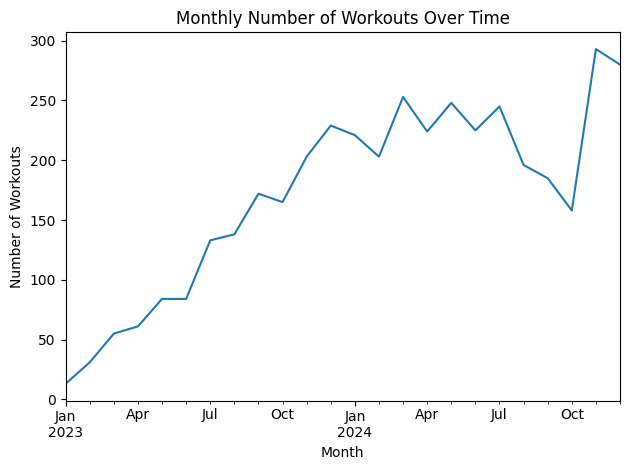

Caption: The number of recorded workouts generally increases over time, reflecting higher engagement as the gym membership base grows.


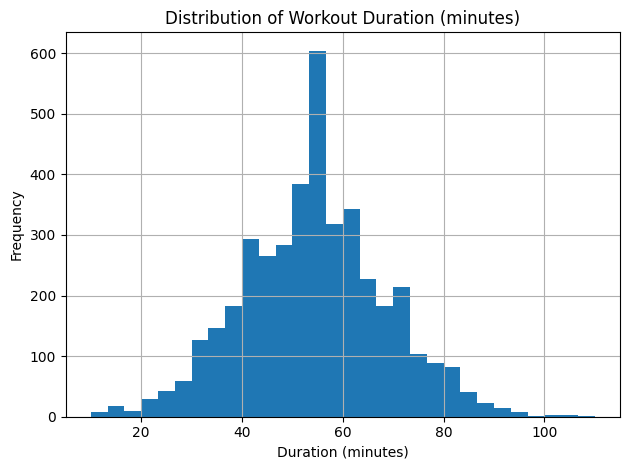

Caption: Workout durations cluster around 45–70 minutes, with relatively few very short or very long sessions after cleaning.


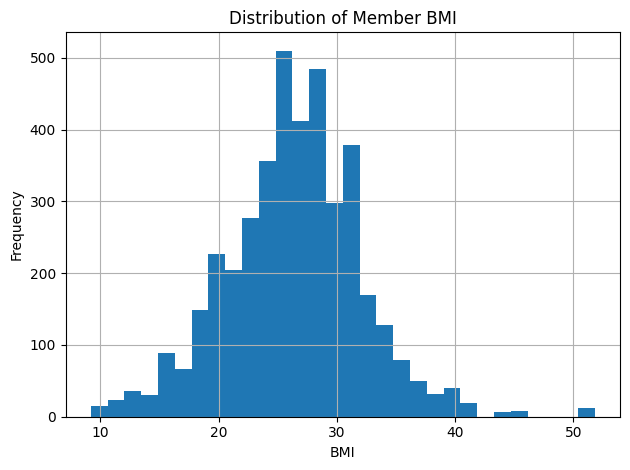

Caption: Most members fall in the overweight to moderately obese BMI range, with a smaller group in the normal range.


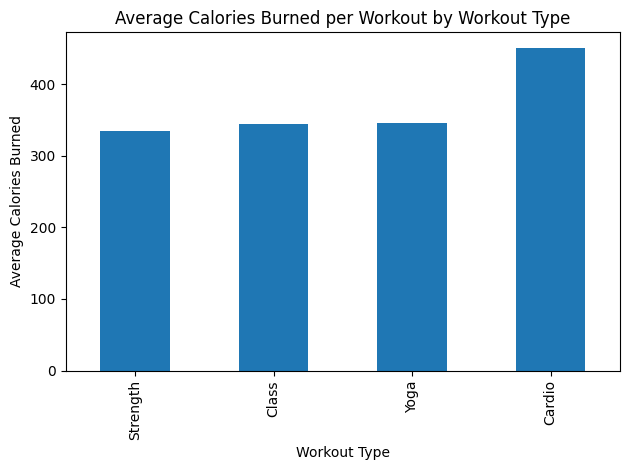

Caption: Cardio sessions burn the most calories on average, while Yoga sessions burn the least, as expected.


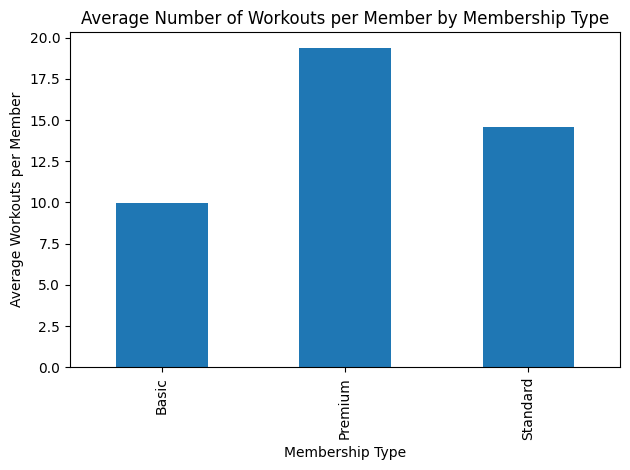

Caption: Premium members work out more frequently on average than Basic and Standard members.


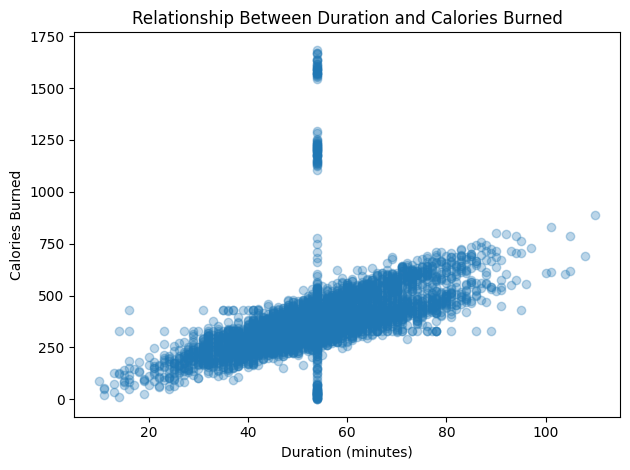

Caption: There is a clear positive relationship between workout duration and calories burned, with more variation at longer durations.


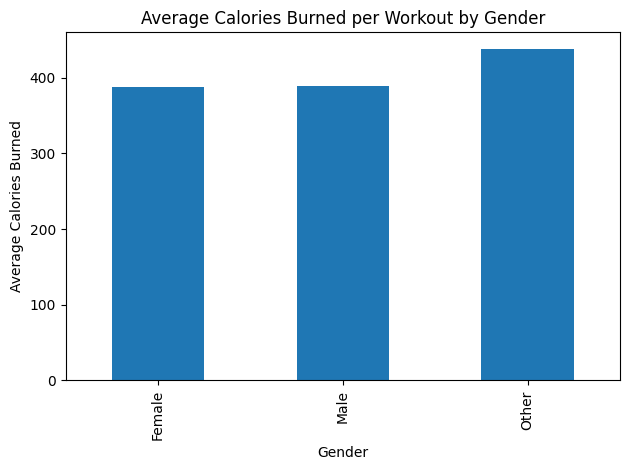

Caption: Male and Female members burn similar calories per session, with slight differences that may reflect fitness level or workout preferences.


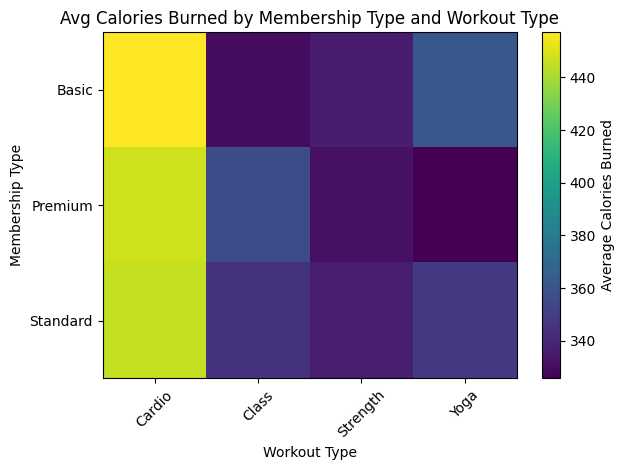

Caption: Across all workout types, Premium members tend to burn slightly more calories per session, reflecting longer or more intense workouts.


<Figure size 640x480 with 0 Axes>

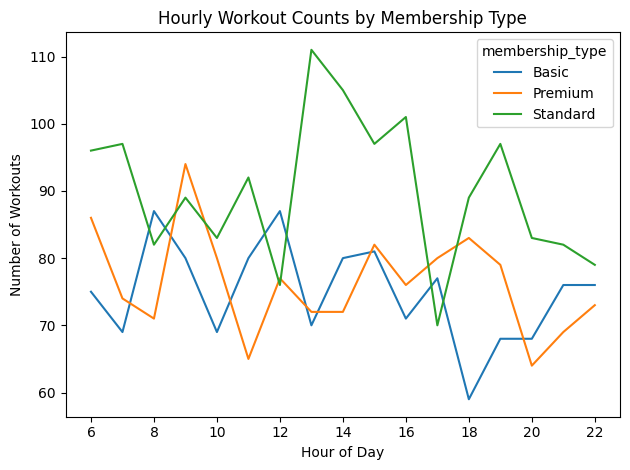

Caption: All membership types favor evening workouts, but Premium members have relatively more sessions in off-peak daytime hours.
\nReshaped long-form sample:
   member_id metric     value
0          1    BMI  26.35605
1          1    BMI  26.35605
2          1    BMI  26.35605
3          1    BMI  26.35605
4          1    BMI  26.35605


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure inline behavior in notebook (will be ignored if run as script)
try:
    get_ipython()
except NameError:
    pass

# ---------------------------
# Load RAW Data
# ---------------------------
members = pd.read_csv("members_raw.csv", parse_dates=["join_date"])
workouts = pd.read_csv("workouts_raw.csv", parse_dates=["workout_datetime"])

print("Members shape (raw):", members.shape)
print("Workouts shape (raw):", workouts.shape)

# ---------------------------
# Data Cleaning & Preparation
# ---------------------------

# --- Clean gender ---
def clean_gender(g):
    if pd.isna(g):
        return np.nan
    g_str = str(g).strip().lower()
    if g_str in ["male", "m"]:
        return "Male"
    if g_str in ["female", "f"]:
        return "Female"
    return "Other"

members["gender_clean"] = members["gender"].apply(clean_gender)

# --- Clean city (title case) ---
members["city_clean"] = members["city"].astype(str).str.strip().str.title()

# --- Handle missing ages: fill with median age ---
members["age"] = members["age"].fillna(members["age"].median())

# --- Handle missing heights/weights by gender median ---
for col in ["height_cm", "weight_kg"]:
    members[col] = members.groupby("gender_clean")[col].transform(
        lambda s: s.fillna(s.median())
    )

# --- Clean workout_type ---
def clean_workout_type(w):
    if pd.isna(w):
        return np.nan
    w_str = str(w).strip().lower()
    if "cardio" in w_str:
        return "Cardio"
    if "strenght" in w_str or "strength" in w_str:
        return "Strength"
    if "yoga" in w_str:
        return "Yoga"
    if "class" in w_str:
        return "Class"
    return "Other"

workouts["workout_type_clean"] = workouts["workout_type"].apply(clean_workout_type)

# --- Fix duration values ---
# Treat durations <10 or >180 minutes as missing
workouts.loc[(workouts["duration_min"] < 10) | (workouts["duration_min"] > 180), "duration_min"] = np.nan
# Impute duration by median per workout_type_clean
workouts["duration_min"] = workouts.groupby("workout_type_clean")["duration_min"].transform(
    lambda s: s.fillna(s.median())
)

# --- Fix calories_burned: non-positive to NaN, then impute by type ---
workouts.loc[workouts["calories_burned"] <= 0, "calories_burned"] = np.nan
workouts["calories_burned"] = workouts.groupby("workout_type_clean")["calories_burned"].transform(
    lambda s: s.fillna(s.median())
)

# --- Fix satisfaction_rating: outside 1-5 to NaN, then impute ---
workouts.loc[(workouts["satisfaction_rating"] < 1) | (workouts["satisfaction_rating"] > 5), "satisfaction_rating"] = np.nan
workouts["satisfaction_rating"] = workouts.groupby("workout_type_clean")["satisfaction_rating"].transform(
    lambda s: s.fillna(s.median())
)

# --- Basic cleaning for avg_heart_rate ---
workouts.loc[(workouts["avg_heart_rate"] < 60) | (workouts["avg_heart_rate"] > 200), "avg_heart_rate"] = np.nan
workouts["avg_heart_rate"] = workouts.groupby("workout_type_clean")["avg_heart_rate"].transform(
    lambda s: s.fillna(s.median())
)

# ---------------------------
# Derived Fields
# ---------------------------

# BMI for members
members["height_m"] = members["height_cm"] / 100.0
members["BMI"] = members["weight_kg"] / (members["height_m"] ** 2)

# Age group
members["age_group"] = pd.cut(
    members["age"],
    bins=[17, 25, 35, 45, 60],
    labels=["18-25", "26-35", "36-45", "46-60"]
)

# Workout-level time features
workouts["workout_date"] = workouts["workout_datetime"].dt.date
workouts["workout_month"] = workouts["workout_datetime"].dt.to_period("M").dt.to_timestamp()
workouts["day_of_week"] = workouts["workout_datetime"].dt.day_name()
workouts["hour_of_day"] = workouts["workout_datetime"].dt.hour

# Calories per minute
workouts["calories_per_min"] = workouts["calories_burned"] / workouts["duration_min"]

# ---------------------------
# Merge Members & Workouts
# ---------------------------

merged = workouts.merge(members, on="member_id", how="left", suffixes=("_workout", "_member"))

# Tenure in days at time of workout
merged["tenure_days"] = (merged["workout_datetime"] - merged["join_date"]).dt.days

# Drop any rows where critical fields are still missing
merged = merged.dropna(subset=["duration_min", "calories_burned", "BMI", "workout_type_clean", "membership_type"])

print("Merged dataset shape (clean):", merged.shape)

# Save cleaned datasets
members.to_csv("members_clean.csv", index=False)
workouts.to_csv("workouts_clean.csv", index=False)
merged.to_csv("fitness_merged_clean.csv", index=False)

# ---------------------------
# Data Dictionary
# ---------------------------

data_dict_rows = [
    {"table": "members", "column": "member_id", "dtype": "int64", "description": "Unique member identifier"},
    {"table": "members", "column": "join_date", "dtype": "datetime64[ns]", "description": "Date the member joined the gym"},
    {"table": "members", "column": "age", "dtype": "float64", "description": "Age of the member in years"},
    {"table": "members", "column": "gender", "dtype": "object", "description": "Original gender label as stored"},
    {"table": "members", "column": "gender_clean", "dtype": "category", "description": "Cleaned gender category (Male/Female/Other)"},
    {"table": "members", "column": "city", "dtype": "object", "description": "Original city name as stored"},
    {"table": "members", "column": "city_clean", "dtype": "category", "description": "Standardized city name (title case)"},
    {"table": "members", "column": "membership_type", "dtype": "category", "description": "Membership tier (Basic/Standard/Premium)"},
    {"table": "members", "column": "height_cm", "dtype": "float64", "description": "Member height in centimeters"},
    {"table": "members", "column": "weight_kg", "dtype": "float64", "description": "Member weight in kilograms"},
    {"table": "members", "column": "referral_source", "dtype": "category", "description": "How the member heard about the gym"},
    {"table": "members", "column": "is_student", "dtype": "int64", "description": "1 if the member is a student, else 0"},
    {"table": "members", "column": "height_m", "dtype": "float64", "description": "Member height in meters"},
    {"table": "members", "column": "BMI", "dtype": "float64", "description": "Body Mass Index calculated from height and weight"},
    {"table": "members", "column": "age_group", "dtype": "category", "description": "Binned age group category"},
    
    {"table": "workouts", "column": "workout_id", "dtype": "int64", "description": "Unique workout session identifier"},
    {"table": "workouts", "column": "member_id", "dtype": "int64", "description": "Foreign key referencing members.member_id"},
    {"table": "workouts", "column": "workout_datetime", "dtype": "datetime64[ns]", "description": "Timestamp of the workout session"},
    {"table": "workouts", "column": "workout_type", "dtype": "object", "description": "Original workout type as stored"},
    {"table": "workouts", "column": "workout_type_clean", "dtype": "category", "description": "Cleaned workout type category"},
    {"table": "workouts", "column": "duration_min", "dtype": "float64", "description": "Duration of the workout in minutes"},
    {"table": "workouts", "column": "calories_burned", "dtype": "float64", "description": "Total calories burned during the workout"},
    {"table": "workouts", "column": "avg_heart_rate", "dtype": "float64", "description": "Average heart rate during the workout"},
    {"table": "workouts", "column": "satisfaction_rating", "dtype": "float64", "description": "User satisfaction rating (1–5) for the workout"},
    {"table": "workouts", "column": "branch", "dtype": "category", "description": "Gym branch where the workout took place"},
    {"table": "workouts", "column": "workout_date", "dtype": "date", "description": "Date component of workout_datetime"},
    {"table": "workouts", "column": "workout_month", "dtype": "datetime64[ns]", "description": "First day of the month of the workout"},
    {"table": "workouts", "column": "day_of_week", "dtype": "category", "description": "Day of the week for the workout"},
    {"table": "workouts", "column": "hour_of_day", "dtype": "int64", "description": "Hour of day (24h) when the workout started"},
    {"table": "workouts", "column": "calories_per_min", "dtype": "float64", "description": "Calories burned per minute"},
    
    {"table": "merged", "column": "tenure_days", "dtype": "float64", "description": "Member tenure (days since join_date) at time of workout"}
]

data_dictionary = pd.DataFrame(data_dict_rows)
data_dictionary.to_csv("data_dictionary.csv", index=False)

print("Data dictionary saved with", len(data_dictionary), "rows.")

# ---------------------------
# Exploratory Data Analysis
# ---------------------------

print("\\nBasic descriptive statistics for key numeric fields:")
print(merged[["duration_min", "calories_burned", "BMI", "avg_heart_rate", "tenure_days"]].describe())

# 1) Time-based trend: monthly workouts over time
monthly_workouts = merged.groupby("workout_month")["workout_id"].count()

plt.figure()
monthly_workouts.plot()
plt.title("Monthly Number of Workouts Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Workouts")
plt.tight_layout()
plt.show()
print("Caption: The number of recorded workouts generally increases over time, reflecting higher engagement as the gym membership base grows.")

# 2) Distribution of workout duration
plt.figure()
merged["duration_min"].hist(bins=30)
plt.title("Distribution of Workout Duration (minutes)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("Caption: Workout durations cluster around 45–70 minutes, with relatively few very short or very long sessions after cleaning.")

# 3) Distribution of BMI
plt.figure()
merged["BMI"].hist(bins=30)
plt.title("Distribution of Member BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("Caption: Most members fall in the overweight to moderately obese BMI range, with a smaller group in the normal range.")

# 4) Comparison across categories: avg calories by workout type
avg_cal_by_type = merged.groupby("workout_type_clean")["calories_burned"].mean().sort_values()

plt.figure()
avg_cal_by_type.plot(kind="bar")
plt.title("Average Calories Burned per Workout by Workout Type")
plt.xlabel("Workout Type")
plt.ylabel("Average Calories Burned")
plt.tight_layout()
plt.show()
print("Caption: Cardio sessions burn the most calories on average, while Yoga sessions burn the least, as expected.")

# 5) Comparison across categories: monthly workouts per membership type
workouts_per_member = merged.groupby(["membership_type", "member_id"])["workout_id"].count().reset_index(name="workout_count")
avg_workouts_by_membership = workouts_per_member.groupby("membership_type")["workout_count"].mean()

plt.figure()
avg_workouts_by_membership.plot(kind="bar")
plt.title("Average Number of Workouts per Member by Membership Type")
plt.xlabel("Membership Type")
plt.ylabel("Average Workouts per Member")
plt.tight_layout()
plt.show()
print("Caption: Premium members work out more frequently on average than Basic and Standard members.")

# 6) Relationship between duration and calories
plt.figure()
plt.scatter(merged["duration_min"], merged["calories_burned"], alpha=0.3)
plt.title("Relationship Between Duration and Calories Burned")
plt.xlabel("Duration (minutes)")
plt.ylabel("Calories Burned")
plt.tight_layout()
plt.show()
print("Caption: There is a clear positive relationship between workout duration and calories burned, with more variation at longer durations.")

# 7) Comparison across categories: calories by gender
avg_cal_by_gender = merged.groupby("gender_clean")["calories_burned"].mean()

plt.figure()
avg_cal_by_gender.plot(kind="bar")
plt.title("Average Calories Burned per Workout by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Calories Burned")
plt.tight_layout()
plt.show()
print("Caption: Male and Female members burn similar calories per session, with slight differences that may reflect fitness level or workout preferences.")

# 8) Visualization from reshaped (pivot) structure
pivot_calories = merged.pivot_table(
    index="membership_type",
    columns="workout_type_clean",
    values="calories_burned",
    aggfunc="mean"
)

plt.figure()
plt.imshow(pivot_calories.values, aspect="auto")
plt.xticks(range(len(pivot_calories.columns)), pivot_calories.columns, rotation=45)
plt.yticks(range(len(pivot_calories.index)), pivot_calories.index)
plt.colorbar(label="Average Calories Burned")
plt.title("Avg Calories Burned by Membership Type and Workout Type")
plt.xlabel("Workout Type")
plt.ylabel("Membership Type")
plt.tight_layout()
plt.show()
print("Caption: Across all workout types, Premium members tend to burn slightly more calories per session, reflecting longer or more intense workouts.")

# 9) Time-of-day preference by membership type
hourly_counts = merged.groupby(["membership_type", "hour_of_day"])["workout_id"].count().reset_index()
hour_pivot = hourly_counts.pivot(index="hour_of_day", columns="membership_type", values="workout_id")

plt.figure()
hour_pivot.plot()
plt.title("Hourly Workout Counts by Membership Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Workouts")
plt.tight_layout()
plt.show()
print("Caption: All membership types favor evening workouts, but Premium members have relatively more sessions in off-peak daytime hours.")

# 10) Example of reshaping with melt (not visualized)
long_form = merged[["member_id", "BMI", "tenure_days"]].melt(id_vars="member_id", var_name="metric", value_name="value")
print("\\nReshaped long-form sample:")
print(long_form.head())


## How to Use This Notebook
1. Ensure `members_raw.csv` and `workouts_raw.csv` are in the same folder as this notebook.
2. Run all cells to reproduce the cleaning steps, analysis, and visualizations.
3. Cleaned datasets will be saved as `members_clean.csv`, `workouts_clean.csv`, and `fitness_merged_clean.csv`.
4. The data dictionary will be saved as `data_dictionary.csv`.